# Sampling vs. contracting the same MPS

Two ways to turn a QAOA circuit into an energy, both running on the *same* Qiskit Aer
matrix-product-state backend:

| | contraction | `MPSSampleEvaluator` |
|---|---|---|
| how the energy is obtained | contract $\langle\psi\vert H_C\vert\psi\rangle$ on the MPS, term by term | draw `shots` bit strings from the MPS and average $H_C(x)$ |
| primitive | `qiskit_aer.primitives.EstimatorV2` with `default_precision = 0` | `BackendSamplerV2` |
| cost driver | one contraction per Pauli term of $H_C$ | one circuit, then a classical pass over the samples |
| error | MPS truncation only | MPS truncation **and** shot noise $\sim\sigma_E/\sqrt{\text{shots}}$ |

**Hypothesis under test.** Sampling should pay off when the *cost operator is dense but the ansatz
is sparse*: the contraction has to be repeated for every one of the $n(n-1)/2$ Pauli terms, while
the sampler runs the (cheap, because the ansatz is sparse) circuit once and pays for $H_C$ only in
the classical post-processing.

**What this notebook measures.** For a depth-one QAOA whose cost operator is a fully connected
graph and whose ansatz is a sparsified version of that graph, the **energy error** and the
**wall-clock evaluation time** of both approaches at the angles returned by `DepthOneScanTrainer`
driven by `EfficientDepthOneEvaluator` -- which is exact at depth one for quadratic cost
operators, and so serves both as the source of the angles and as the reference energy.

Because the backend is shared, bond dimension, truncation threshold and thread count can be
matched exactly, and the measured difference is attributable to the estimator alone.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2

from qaoa_training_pipeline.evaluation import EfficientDepthOneEvaluator, MPSSampleEvaluator
from qaoa_training_pipeline.evaluation.aer_interface import AerEvaluator
from qaoa_training_pipeline.training.parameter_scanner import DepthOneScanTrainer
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator

In [2]:
# --- configuration of the benchmark -------------------------------------------------
SEED = 42

NUM_QUBITS = 16        # number of nodes of the fully connected cost graph
MEAN_DEGREE = 3        # mean degree of the sparsified ansatz
BOND_DIM = 64          # chi of the shared Aer MPS backend
TRUNCATION = 1e-16     # MPS truncation threshold of the shared backend
SHOTS = 4000           # shots of MPSSampleEvaluator
MAX_THREADS = 10       # Aer threads, identical for both
REPEATS = 4            # timed repetitions per data point
SCAN_POINTS = 15       # grid resolution of the depth-one scan

# Cheaper settings for the parameter sweeps further down.
SWEEP_SCAN_POINTS = 7
SWEEP_BOND_DIM = 32
SWEEP_SHOTS = 4000
DENSITY_QUBITS = 24    # register used for the cost-operator density sweep

## 1. Putting both evaluators on the same backend

The contraction side needs a little care, because the obvious candidate is not a contraction at
all. `MPSAerEvaluator` builds a `qiskit_ibm_runtime.EstimatorV2` around an `AerSimulator`; handed
a plain `BackendV2`, the runtime drops into local testing mode and instantiates a
`qiskit.primitives.BackendEstimatorV2`, which is **shot-based** -- it turns a precision into
`ceil(1/precision**2)` shots, measures, and estimates. Against `MPSSampleEvaluator` that is a
comparison of two post-processing routines applied to statistically identical data, not of
contraction against sampling.

`qiskit_aer.primitives.EstimatorV2` takes the other route: it computes the expectation value
exactly on the simulated state and only then adds Gaussian noise of width `precision`. Setting
`default_precision = 0` disables that noise and leaves a genuine contraction. The repo's
`AerEvaluator` wraps any `BaseEstimatorV2`, so no new evaluator class is needed.

Everything that affects accuracy is passed identically to both: `chi`, the truncation threshold
and the thread count. Note that `MPSSampleEvaluator` leaves the threshold at Aer's default of
`1e-16`, which is what `TRUNCATION` reproduces on the contraction side -- worth pinning
explicitly, since other Aer-based evaluators in this repo default it to `1e-5`.

In [3]:
def make_contraction_evaluator(bond_dim=BOND_DIM, threads=MAX_THREADS) -> AerEvaluator:
    """Exact <psi|H_C|psi> contracted on the Aer MPS: Aer's own estimator at precision 0."""
    estimator = AerEstimatorV2(
        options={
            "backend_options": {
                "method": "matrix_product_state",
                "matrix_product_state_max_bond_dimension": bond_dim,
                "matrix_product_state_truncation_threshold": TRUNCATION,
                "max_parallel_threads": threads,
            },
            "default_precision": 0.0,
        }
    )

    return AerEvaluator(estimator)


def make_sample_evaluator(
    bond_dim=BOND_DIM, shots=SHOTS, threads=MAX_THREADS
) -> MPSSampleEvaluator:
    """Sampling from the same backend, with the same bond dimension and thread count."""
    return MPSSampleEvaluator(chi=bond_dim, shots=shots, max_parallel_threads=threads)

## 2. The problem: a fully connected cost operator

The cost operator is the complete graph $K_n$ with random Gaussian couplings,

$$H_C = \sum_{i<j} w_{ij} Z_i Z_j , \qquad w_{ij}\sim\mathcal{N}(0,1),$$

which gives $n(n-1)/2$ Pauli terms -- the dense regime the hypothesis is about. Random weights
(rather than unit weights) are what make a *weight-based* sparsification of the ansatz meaningful.

In [4]:
def weighted_complete_graph(num_nodes: int, seed: int = SEED) -> nx.Graph:
    """Complete graph on `num_nodes` nodes with i.i.d. standard normal edge weights."""
    generator = np.random.default_rng(seed)
    graph = nx.Graph()
    graph.add_nodes_from(range(num_nodes))
    for node1 in range(num_nodes):
        for node2 in range(node1 + 1, num_nodes):
            graph.add_edge(node1, node2, weight=float(generator.normal()))

    return graph


cost_graph = weighted_complete_graph(NUM_QUBITS)
cost_op = graph_to_operator(cost_graph)

print(f"qubits:      {cost_op.num_qubits}")
print(f"Pauli terms: {len(cost_op)}")

qubits:      16
Pauli terms: 120


## 3. How the sparsified ansatz is obtained

Both evaluators take the custom ansatz as a **`SparsePauliOp`**, which they hand to `qaoa_ansatz`
as the generator of the cost layer: a term $w\,Z_iZ_j$ becomes the rotation $R_{zz}(2w\gamma)$.
So the ansatz is just a *subgraph* of the cost graph, converted with the same `graph_to_operator`
used for $H_C$ itself.

`EfficientDepthOneEvaluator`, the exact reference, is the odd one out: it wants a `QuantumCircuit`
of `Rzz` gates and reads an edge of weight $w$ off every `rzz(2*w*gamma, i, j)`. Both
representations are built from the same subgraph, and section 5 checks that they agree.

Sparsification keeps the $m$ couplings with the largest $|w_{ij}|$ -- the natural approximation of
$e^{-i\gamma H_C}$: drop the rotations that rotate the least. One detail matters: every qubit must
be touched by at least one gate, so `_attach_isolated_nodes` gives any orphaned node its heaviest
incident edge back. Without it the ansatz operator would act on fewer qubits than $H_C$.

In [5]:
def _attach_isolated_nodes(sub_graph: nx.Graph, graph: nx.Graph) -> nx.Graph:
    """Give every isolated qubit its heaviest incident edge back."""
    for node in graph.nodes():
        if sub_graph.degree(node) == 0:
            node1, node2, data = max(
                graph.edges(node, data=True), key=lambda edge: abs(edge[2]["weight"])
            )
            sub_graph.add_edge(node1, node2, **data)

    return sub_graph


def edges_for_degree(num_nodes: int, mean_degree: float) -> int:
    """Number of edges that gives the requested mean degree."""
    return max(1, int(round(mean_degree * num_nodes / 2)))


def top_weight_subgraph(graph: nx.Graph, num_edges: int) -> nx.Graph:
    """Sparsify by keeping the `num_edges` couplings with the largest magnitude."""
    ranked = sorted(graph.edges(data=True), key=lambda edge: -abs(edge[2]["weight"]))

    sub_graph = nx.Graph()
    sub_graph.add_nodes_from(graph.nodes())
    sub_graph.add_edges_from(ranked[:num_edges])

    return _attach_isolated_nodes(sub_graph, graph)


def ansatz_operator(sub_graph: nx.Graph):
    """The sparsified ansatz as a SparsePauliOp -- what both MPS evaluators consume."""
    return graph_to_operator(sub_graph)


def ansatz_circuit(sub_graph: nx.Graph) -> QuantumCircuit:
    """The same ansatz as an Rzz network -- what EfficientDepthOneEvaluator consumes."""
    gamma = Parameter("gamma")
    circuit = QuantumCircuit(sub_graph.number_of_nodes())
    for node1, node2, data in sub_graph.edges(data=True):
        circuit.rzz(2 * data.get("weight", 1.0) * gamma, node1, node2)

    return circuit

In [6]:
ansatz_graph = top_weight_subgraph(cost_graph, edges_for_degree(NUM_QUBITS, MEAN_DEGREE))
edge_ratio = ansatz_graph.number_of_edges() / cost_graph.number_of_edges()

print(f"cost operator : {cost_graph.number_of_edges()} edges (fully connected)")
print(f"ansatz        : {ansatz_graph.number_of_edges()} edges ({edge_ratio:.1%} of the cost operator)")
print(f"mean degree   : {2 * ansatz_graph.number_of_edges() / NUM_QUBITS:.2f}")

cost operator : 120 edges (fully connected)
ansatz        : 24 edges (20.0% of the cost operator)
mean degree   : 3.00


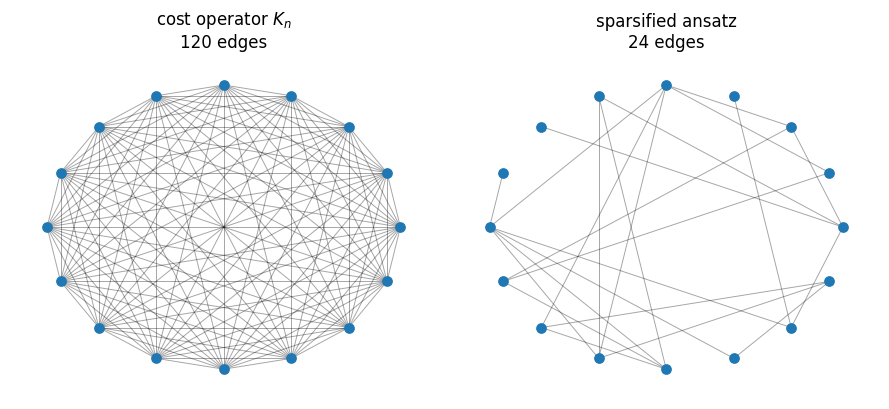

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
positions = nx.circular_layout(cost_graph)

for axis, (title, graph) in zip(
    axes, [("cost operator $K_n$", cost_graph), ("sparsified ansatz", ansatz_graph)]
):
    nx.draw_networkx_edges(graph, positions, ax=axis, alpha=0.35, width=0.7)
    nx.draw_networkx_nodes(graph, positions, ax=axis, node_size=45, node_color="tab:blue")
    axis.set_title(f"{title}\n{graph.number_of_edges()} edges")
    axis.set_axis_off()

fig.tight_layout()
plt.show()

## 4. Angles from `DepthOneScanTrainer` + `EfficientDepthOneEvaluator`

The scan runs on the *dense* cost operator with the *sparse* ansatz, so the landscape is the true
depth-one landscape of the approximate circuit. Since `EfficientDepthOneEvaluator` is exact, the
optimum it returns is the point at which both evaluators are benchmarked, and its energy is the
reference they are scored against.

In [8]:
def scan_angles(operator, sub_graph, num_points=SCAN_POINTS):
    """Depth-one scan with the exact evaluator. Returns (angles, result, trainer)."""
    trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=num_points)
    result = trainer.provide_params(operator, ansatz_circuit=ansatz_circuit(sub_graph))

    return list(result["optimized_params"]), result, trainer


start = perf_counter()
angles, scan_result, scanner = scan_angles(cost_op, ansatz_graph)
scan_time = perf_counter() - start

beta, gamma = angles
print(f"scan over {SCAN_POINTS}x{SCAN_POINTS} points took {scan_time:.2f} s "
      f"({np.mean(scan_result['energy_evaluation_time']) * 1e3:.1f} ms per energy)")
print(f"optimal angles: beta = {beta:.4f}, gamma = {gamma:.4f}")
print(f"reference energy at the optimum: {scan_result['energy']:.6f}")

scan over 15x15 points took 6.45 s (28.7 ms per energy)
optimal angles: beta = 0.4488, gamma = 0.4488
reference energy at the optimum: 4.661396


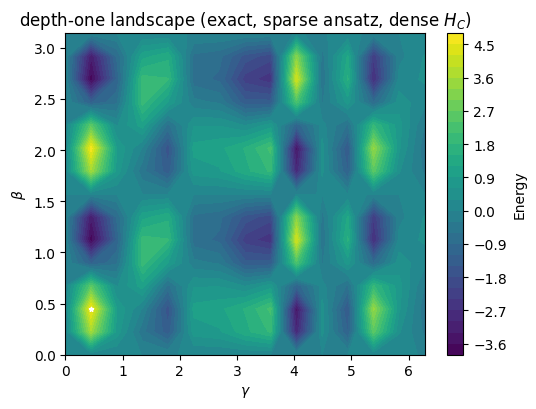

In [9]:
fig, axis = plt.subplots(1, 1, figsize=(5.5, 4.2))
scanner.plot(axis=axis, fig=fig)
axis.set_title("depth-one landscape (exact, sparse ansatz, dense $H_C$)")
fig.tight_layout()
plt.show()

## 5. Cross-check

Two things to confirm before timing anything. The contraction must reproduce the exact energy to
simulator precision -- if it does not, either the ansatz conventions disagree between the
`SparsePauliOp` and the `Rzz` circuit, or `precision = 0` did not take effect and we are secretly
sampling. The sampler must agree to within shot noise.

The check runs at a small size and a large bond dimension so that MPS truncation is not a factor.

In [10]:
check_graph = weighted_complete_graph(8, seed=7)
check_cost_op = graph_to_operator(check_graph)
check_ansatz = top_weight_subgraph(check_graph, edges_for_degree(8, 3))
check_angles = [0.35, 0.62]

exact_energy = EfficientDepthOneEvaluator().evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_circuit(check_ansatz)
)
contracted = make_contraction_evaluator(bond_dim=256).evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
)
sampled = make_sample_evaluator(bond_dim=256, shots=200_000).evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
)

print(f"EfficientDepthOneEvaluator : {exact_energy:.10f}")
print(f"contraction                : {contracted:.10f}   (diff {abs(contracted - exact_energy):.2e})")
print(f"MPSSampleEvaluator         : {sampled:.10f}   (diff {abs(sampled - exact_energy):.2e})")

# Determinism is the signature of a real contraction: sampling would not repeat exactly.
repeats = [
    make_contraction_evaluator(bond_dim=256).evaluate(
        check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
    )
    for _ in range(3)
]
print(f"\ncontraction repeated 3x, spread: {np.std(repeats):.2e}")

assert abs(contracted - exact_energy) < 1e-8, "the contraction is not exact"
assert abs(sampled - exact_energy) < 0.05, "MPSSampleEvaluator disagrees with the exact result"

EfficientDepthOneEvaluator : 0.7466377794
contraction                : 0.7466377794   (diff 3.69e-11)
MPSSampleEvaluator         : 0.7607559185   (diff 1.41e-02)

contraction repeated 3x, spread: 1.11e-16


## 6. Head-to-head at the scanned angles

`timed` warms the caches first (`MPSSampleEvaluator` caches the digest of $H_C$ and the per-term
bit indices; the estimator transpiles on first use), then times `REPEATS` further calls -- what an
optimizer would pay per iteration.

The contraction is deterministic, so its error is a single number. The sampler is not, so its
error is the mean absolute deviation over the repetitions and `spread` is the standard deviation
of the estimates, which should sit near the shot-noise floor $\sigma_E/\sqrt{\text{shots}}$
computed from its own counts.

In [11]:
def timed(func, *args, repeats=REPEATS, **kwargs):
    """Warm up once, then time `repeats` calls. Returns (values, times)."""
    func(*args, **kwargs)

    values, times = [], []
    for _ in range(repeats):
        start = perf_counter()
        values.append(float(np.real(func(*args, **kwargs))))
        times.append(perf_counter() - start)

    return np.array(values), np.array(times)


def head_to_head(
    operator, sub_graph, params, bond_dim=BOND_DIM, shots=SHOTS, repeats=REPEATS
):
    """Accuracy and evaluation time of contraction and sampling against the exact reference."""
    circuit, ansatz_op = ansatz_circuit(sub_graph), ansatz_operator(sub_graph)

    exact_values, exact_times = timed(
        EfficientDepthOneEvaluator().evaluate,
        operator,
        params,
        ansatz_circuit=circuit,
        repeats=repeats,
    )
    reference = float(exact_values[0])

    contraction = make_contraction_evaluator(bond_dim=bond_dim)
    contracted_values, contracted_times = timed(
        contraction.evaluate, operator, params, ansatz_circuit=ansatz_op, repeats=repeats
    )

    sampler = make_sample_evaluator(bond_dim=bond_dim, shots=shots)
    sampled_values, sampled_times = timed(
        sampler.evaluate, operator, params, ansatz_circuit=ansatz_op, repeats=repeats
    )

    per_sample = np.array(sampler.energies(sampler.get_results_from_last_iteration()["counts"]))
    shot_noise = float(per_sample.std() / np.sqrt(shots))

    return {
        "ansatz_edges": sub_graph.number_of_edges(),
        "cost_terms": len(operator),
        "reference": reference,
        "exact_time": float(np.median(exact_times)),
        "contraction_energy": float(contracted_values.mean()),
        "contraction_error": float(np.abs(contracted_values - reference).mean()),
        "contraction_time": float(np.median(contracted_times)),
        "sampler_energy": float(sampled_values.mean()),
        "sampler_error": float(np.abs(sampled_values - reference).mean()),
        "sampler_spread": float(sampled_values.std()),
        "sampler_time": float(np.median(sampled_times)),
        "shot_noise": shot_noise,
    }

In [12]:
main = head_to_head(cost_op, ansatz_graph, angles)

print(f"n = {NUM_QUBITS} qubits, {main['cost_terms']} cost terms, "
      f"{main['ansatz_edges']} ansatz edges, chi = {BOND_DIM}, shots = {SHOTS}")
print(f"angles from the scan: beta = {beta:.4f}, gamma = {gamma:.4f}")
print()
print(f"{'evaluator':<28}{'energy':>12}{'abs. error':>13}{'time [s]':>11}")
print("-" * 64)
print(f"{'EfficientDepthOne (exact)':<28}{main['reference']:>12.5f}{'-':>13}"
      f"{main['exact_time']:>11.4f}")
print(f"{'contraction':<28}{main['contraction_energy']:>12.5f}"
      f"{main['contraction_error']:>13.2e}{main['contraction_time']:>11.4f}")
print(f"{'MPSSampleEvaluator':<28}{main['sampler_energy']:>12.5f}"
      f"{main['sampler_error']:>13.2e}{main['sampler_time']:>11.4f}")
print()
print(f"sampler spread over {REPEATS} repetitions:   {main['sampler_spread']:.3e}")
print(f"shot-noise floor sigma_E/sqrt(shots): {main['shot_noise']:.3e}")
print(f"time ratio sampler/contraction:       {main['sampler_time'] / main['contraction_time']:.2f}")

n = 16 qubits, 120 cost terms, 24 ansatz edges, chi = 64, shots = 4000
angles from the scan: beta = 0.4488, gamma = 0.4488

evaluator                         energy   abs. error   time [s]
----------------------------------------------------------------
EfficientDepthOne (exact)        4.66140            -     0.0265
contraction                      4.66140     6.73e-11     0.2548
MPSSampleEvaluator               4.67902     5.34e-02     0.6222

sampler spread over 4 repetitions:   5.582e-02
shot-noise floor sigma_E/sqrt(shots): 1.423e-01
time ratio sampler/contraction:       2.44


At this size the contraction wins on both counts: it is exact rather than shot-noise limited, and
it is the faster of the two. The rest of the notebook is about finding where that reverses.

## 7. Accuracy against cost

The two have different knobs -- bond dimension for the contraction, shots for the sampler -- so
the comparison is the error-versus-time front. The contraction has no statistical floor: once
$\chi$ is large enough for the ansatz its error drops to simulator precision and stays there. The
sampler's error falls only as $1/\sqrt{\text{shots}}$.

In [13]:
bond_dims = [2, 4, 8, 16, 32, 64]
shot_counts = [250, 1000, 4000, 16000]

main_operator = ansatz_operator(ansatz_graph)
reference = main["reference"]

contraction_front = []
for chi in bond_dims:
    evaluator = make_contraction_evaluator(bond_dim=chi)
    values, times = timed(
        evaluator.evaluate, cost_op, angles, ansatz_circuit=main_operator, repeats=2
    )
    contraction_front.append(
        (chi, float(np.abs(values - reference).mean()), float(np.median(times)))
    )
    print(f"contraction        chi={chi:5d}  error={contraction_front[-1][1]:.3e}  "
          f"time={contraction_front[-1][2]:.3f} s")

sampler_front = []
for shots in shot_counts:
    evaluator = make_sample_evaluator(bond_dim=BOND_DIM, shots=shots)
    values, times = timed(
        evaluator.evaluate, cost_op, angles, ansatz_circuit=main_operator, repeats=REPEATS
    )
    sampler_front.append((shots, float(np.abs(values - reference).mean()), float(np.median(times))))
    print(f"MPSSampleEvaluator shots={shots:5d}  error={sampler_front[-1][1]:.3e}  "
          f"time={sampler_front[-1][2]:.3f} s")

sigma_energy = main["shot_noise"] * np.sqrt(SHOTS)
print(f"\nstd of H_C(x) over the samples: sigma_E = {sigma_energy:.3f}")

contraction        chi=    2  error=6.548e-01  time=0.043 s
contraction        chi=    4  error=1.661e+00  time=0.043 s
contraction        chi=    8  error=6.221e-01  time=0.054 s
contraction        chi=   16  error=2.091e-02  time=0.098 s
contraction        chi=   32  error=1.149e-01  time=0.276 s
contraction        chi=   64  error=6.727e-11  time=0.253 s
MPSSampleEvaluator shots=  250  error=4.171e-01  time=0.163 s
MPSSampleEvaluator shots= 1000  error=2.560e-01  time=0.267 s
MPSSampleEvaluator shots= 4000  error=1.969e-01  time=0.632 s
MPSSampleEvaluator shots=16000  error=3.783e-02  time=1.954 s

std of H_C(x) over the samples: sigma_E = 8.998


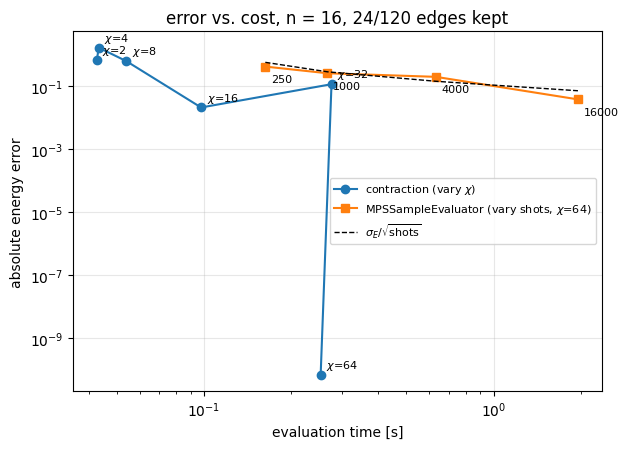

In [14]:
fig, axis = plt.subplots(1, 1, figsize=(6.4, 4.6))

axis.plot([row[2] for row in contraction_front],
          [max(row[1], 1e-16) for row in contraction_front],
          "o-", label=r"contraction (vary $\chi$)")
for chi, error, duration in contraction_front:
    axis.annotate(rf"$\chi$={chi}", (duration, max(error, 1e-16)),
                  textcoords="offset points", xytext=(4, 5), fontsize=8)

axis.plot([row[2] for row in sampler_front], [row[1] for row in sampler_front],
          "s-", label=f"MPSSampleEvaluator (vary shots, $\\chi$={BOND_DIM})")
for shots, error, duration in sampler_front:
    axis.annotate(f"{shots}", (duration, error), textcoords="offset points",
                  xytext=(4, -11), fontsize=8)

axis.plot([row[2] for row in sampler_front],
          sigma_energy / np.sqrt(np.array(shot_counts, dtype=float)),
          "k--", lw=1, label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")

axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("evaluation time [s]")
axis.set_ylabel("absolute energy error")
axis.set_title(f"error vs. cost, n = {NUM_QUBITS}, "
               f"{main['ansatz_edges']}/{main['cost_terms']} edges kept")
axis.legend(fontsize=8)
axis.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Ansatz sparsity sweep

The cost operator stays fully connected while the ansatz grows from a few percent of the edges up
to the full graph. Sparsifying the ansatz makes the circuit cheaper for *both* methods, so what
this sweep really shows is how much of each one's bill the circuit actually is.

In [15]:
total_edges = cost_graph.number_of_edges()
fractions = [0.03, 0.06, 0.12, 0.25, 0.5, 0.75, 1.0]
sparsity_rows = []

for fraction in fractions:
    sub_graph = top_weight_subgraph(cost_graph, max(1, int(round(fraction * total_edges))))
    sweep_angles, _, _ = scan_angles(cost_op, sub_graph, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        cost_op, sub_graph, sweep_angles,
        bond_dim=SWEEP_BOND_DIM, shots=SWEEP_SHOTS, repeats=3,
    )
    row["fraction"] = sub_graph.number_of_edges() / total_edges
    sparsity_rows.append(row)

    print(f"edges={row['ansatz_edges']:4d} ({row['fraction']:5.1%})  "
          f"contraction: {row['contraction_time']:6.3f} s / err {row['contraction_error']:.2e}   "
          f"sampler: {row['sampler_time']:6.3f} s / err {row['sampler_error']:.2e}   "
          f"ratio {row['sampler_time'] / row['contraction_time']:.2f}")

edges=  10 ( 8.3%)  contraction:  0.045 s / err 7.77e-14   sampler:  0.310 s / err 6.89e-02   ratio 6.83
edges=  12 (10.0%)  contraction:  0.045 s / err 1.28e-10   sampler:  0.328 s / err 1.39e-01   ratio 7.28
edges=  16 (13.3%)  contraction:  0.052 s / err 7.27e-11   sampler:  0.370 s / err 5.86e-02   ratio 7.15
edges=  30 (25.0%)  contraction:  0.304 s / err 8.38e-01   sampler:  0.687 s / err 7.56e-01   ratio 2.26
edges=  60 (50.0%)  contraction:  0.483 s / err 5.15e-01   sampler:  0.912 s / err 7.66e-01   ratio 1.89
edges=  90 (75.0%)  contraction:  0.706 s / err 1.85e-01   sampler:  1.158 s / err 1.40e-01   ratio 1.64
edges= 120 (100.0%)  contraction:  0.849 s / err 6.64e-01   sampler:  1.273 s / err 1.16e-01   ratio 1.50


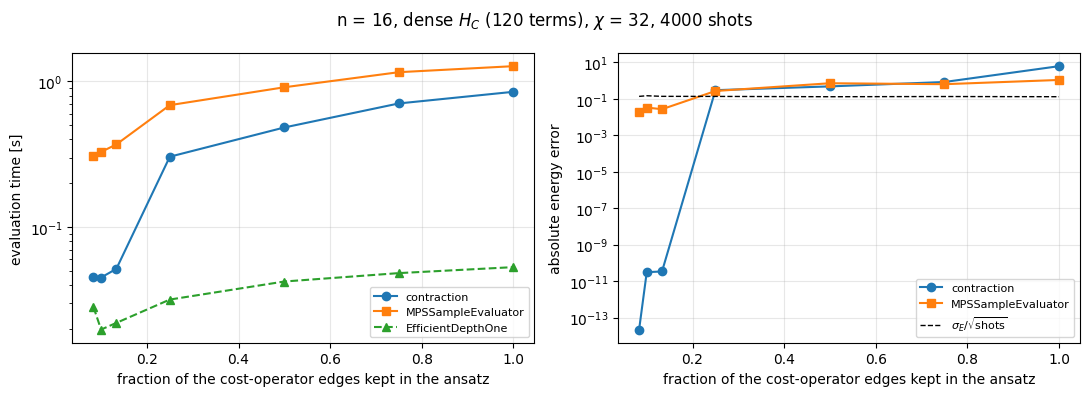

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
edge_fraction = [row["fraction"] for row in sparsity_rows]

axes[0].plot(edge_fraction, [row["contraction_time"] for row in sparsity_rows], "o-",
             label="contraction")
axes[0].plot(edge_fraction, [row["sampler_time"] for row in sparsity_rows], "s-",
             label="MPSSampleEvaluator")
axes[0].plot(edge_fraction, [row["exact_time"] for row in sparsity_rows], "^--",
             label="EfficientDepthOne")
axes[0].set_yscale("log")
axes[0].set_ylabel("evaluation time [s]")
axes[0].legend(fontsize=8)

axes[1].plot(edge_fraction,
             [max(row["contraction_error"]/row["reference"], 1e-16) for row in sparsity_rows], "o-",
             label="contraction")
axes[1].plot(edge_fraction, [row["sampler_error"]/row["reference"] for row in sparsity_rows], "s-",
             label="MPSSampleEvaluator")
axes[1].plot(edge_fraction, [row["shot_noise"] for row in sparsity_rows], "k--", lw=1,
             label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")
axes[1].set_yscale("log")
axes[1].set_ylabel("absolute energy error")
axes[1].legend(fontsize=8)

for axis in axes:
    axis.set_xlabel("fraction of the cost-operator edges kept in the ansatz")
    axis.grid(alpha=0.3)

fig.suptitle(f"n = {NUM_QUBITS}, dense $H_C$ ({total_edges} terms), "
             f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots")
fig.tight_layout()
plt.show()

## 9. Cost-operator density sweep

The other half of the hypothesis, and the one that separates the two methods most directly: hold
the ansatz fixed and sparse, and vary the **density of $H_C$**. The circuit is then identical at
every point, so the slopes are pure per-term cost -- one contraction per Pauli term on one side,
one classical pass over the samples on the other.

The reference energy changes at every point, so the shot-noise floor is plotted alongside the
errors rather than quoted once.

In [17]:
density_graph = weighted_complete_graph(DENSITY_QUBITS, seed=SEED)
density_ansatz = top_weight_subgraph(
    density_graph, edges_for_degree(DENSITY_QUBITS, MEAN_DEGREE)
)
density_total = density_graph.number_of_edges()
density_rng = np.random.default_rng(SEED)
all_edges = list(density_graph.edges(data=True))

density_rows = []
for fraction in [0.1, 0.25, 0.5, 0.75, 1.0]:
    keep = max(1, int(round(fraction * density_total)))
    chosen = density_rng.choice(len(all_edges), size=keep, replace=False)

    partial = nx.Graph()
    partial.add_nodes_from(density_graph.nodes())
    partial.add_edges_from(all_edges[index] for index in chosen)
    partial_op = graph_to_operator(partial)

    density_angles, _, _ = scan_angles(partial_op, density_ansatz, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        partial_op, density_ansatz, density_angles,
        bond_dim=SWEEP_BOND_DIM, shots=SWEEP_SHOTS, repeats=3,
    )
    density_rows.append(row)

    print(f"terms={row['cost_terms']:5d} ({fraction:5.0%} of K_n)  "
          f"contraction: {row['contraction_time']:6.3f} s / err {row['contraction_error']:.2e}   "
          f"sampler: {row['sampler_time']:6.3f} s / err {row['sampler_error']:.2e}   "
          f"ratio {row['sampler_time'] / row['contraction_time']:.2f}")

terms=   28 (  10% of K_n)  contraction:  0.218 s / err 1.80e-01   sampler:  0.836 s / err 2.11e-01   ratio 3.84
terms=   69 (  25% of K_n)  contraction:  0.342 s / err 7.22e-01   sampler:  0.905 s / err 5.64e-01   ratio 2.65
terms=  138 (  50% of K_n)  contraction:  0.575 s / err 4.46e-02   sampler:  1.016 s / err 1.08e-01   ratio 1.77
terms=  207 (  75% of K_n)  contraction:  0.928 s / err 1.78e-01   sampler:  1.100 s / err 1.55e-01   ratio 1.19
terms=  276 ( 100% of K_n)  contraction:  1.068 s / err 9.77e-01   sampler:  1.498 s / err 6.56e-01   ratio 1.40


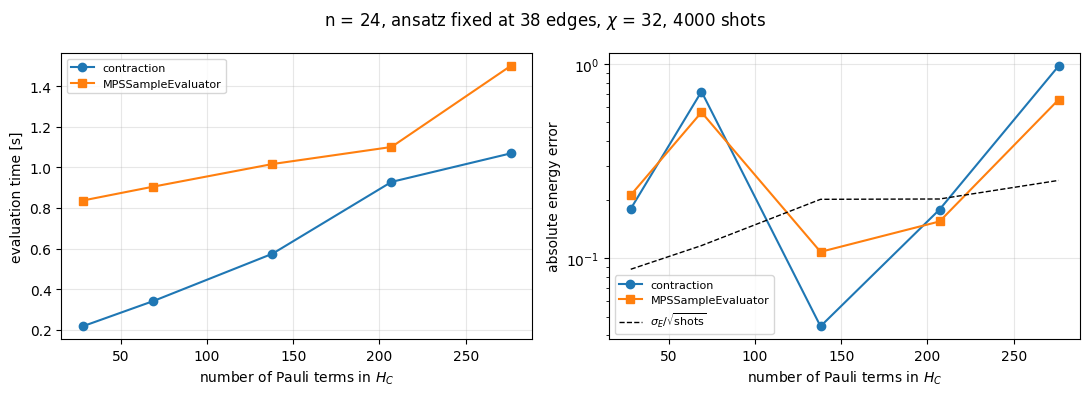

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
term_counts = [row["cost_terms"] for row in density_rows]

axes[0].plot(term_counts, [row["contraction_time"] for row in density_rows], "o-",
             label="contraction")
axes[0].plot(term_counts, [row["sampler_time"] for row in density_rows], "s-",
             label="MPSSampleEvaluator")
axes[0].set_ylabel("evaluation time [s]")
axes[0].legend(fontsize=8)

axes[1].plot(term_counts, [max(row["contraction_error"], 1e-16) for row in density_rows], "o-",
             label="contraction")
axes[1].plot(term_counts, [row["sampler_error"] for row in density_rows], "s-",
             label="MPSSampleEvaluator")
axes[1].plot(term_counts, [row["shot_noise"] for row in density_rows], "k--", lw=1,
             label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")
axes[1].set_yscale("log")
axes[1].set_ylabel("absolute energy error")
axes[1].legend(fontsize=8)

for axis in axes:
    axis.set_xlabel("number of Pauli terms in $H_C$")
    axis.grid(alpha=0.3)

fig.suptitle(f"n = {DENSITY_QUBITS}, ansatz fixed at {density_ansatz.number_of_edges()} edges, "
             f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots")
fig.tight_layout()
plt.show()

This is the mechanism behind the whole comparison. The contraction repeats itself once per Pauli
term, so its time is close to linear in the number of terms with a slope set by $\chi$ and $n$.
The sampler runs the circuit once no matter how dense $H_C$ is; its only exposure to the density
is the classical scoring pass, which is far cheaper per term. A dense cost operator is therefore
what tips the balance -- exactly as the hypothesis says, though it takes a large enough $n$ for
the effect to overcome the sampler's fixed cost of `shots` circuit executions.

## 10. Scaling with the size of the register: the crossover

Both effects at once, and the headline result. The mean degree of the ansatz is held fixed while
$n$ grows, so the cost operator densifies as $n^2$ while the ansatz only grows as $n$. The angles
are re-scanned at every size.

Above the crossover the contraction is also no longer exact: the top-$|w|$ ansatz is sparse but
*long-range*, and it entangles more than $\chi$ = `SWEEP_BOND_DIM` can hold, so both errors drift
up together. Past that point the contraction is paying more and more for an answer that is no
better than the sampled one.

In [25]:
sizes = [8, 12, 16, 20, 24, 28, 32, 36, 40]
scaling_rows = []

for num_qubits in sizes:
    graph = weighted_complete_graph(num_qubits, seed=SEED)
    operator = graph_to_operator(graph)
    sub_graph = top_weight_subgraph(graph, edges_for_degree(num_qubits, MEAN_DEGREE))

    size_angles, _, _ = scan_angles(operator, sub_graph, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        operator, sub_graph, size_angles,
        bond_dim=SWEEP_BOND_DIM, shots=SWEEP_SHOTS, repeats=2,
    )
    row["num_qubits"] = num_qubits
    scaling_rows.append(row)

    print(f"n={num_qubits:3d}  terms={row['cost_terms']:5d}  ansatz={row['ansatz_edges']:4d}  "
          f"contraction: {row['contraction_time']:7.3f} s / err {row['contraction_error']:.2e}   "
          f"sampler: {row['sampler_time']:7.3f} s / err {row['sampler_error']:.2e}   "
          f"ratio {row['sampler_time'] / row['contraction_time']:.2f}")

n=  8  terms=   28  ansatz=  12  contraction:   0.013 s / err 5.99e-11   sampler:   0.097 s / err 3.13e-02   ratio 7.59
n= 12  terms=   66  ansatz=  18  contraction:   0.032 s / err 1.76e-11   sampler:   0.196 s / err 6.52e-02   ratio 6.15
n= 16  terms=  120  ansatz=  24  contraction:   0.247 s / err 2.09e-03   sampler:   0.552 s / err 1.93e-01   ratio 2.24
n= 20  terms=  190  ansatz=  30  contraction:   0.465 s / err 1.18e-01   sampler:   0.752 s / err 1.34e-01   ratio 1.62
n= 24  terms=  276  ansatz=  38  contraction:   0.855 s / err 9.77e-01   sampler:   1.042 s / err 7.90e-01   ratio 1.22
n= 28  terms=  378  ansatz=  44  contraction:   1.700 s / err 2.10e-01   sampler:   1.488 s / err 5.69e-01   ratio 0.87
n= 32  terms=  496  ansatz=  51  contraction:   2.754 s / err 2.07e+00   sampler:   2.093 s / err 2.24e+00   ratio 0.76
n= 36  terms=  630  ansatz=  55  contraction:   3.816 s / err 8.63e-01   sampler:   2.185 s / err 7.26e-01   ratio 0.57
n= 40  terms=  780  ansatz=  64  contrac

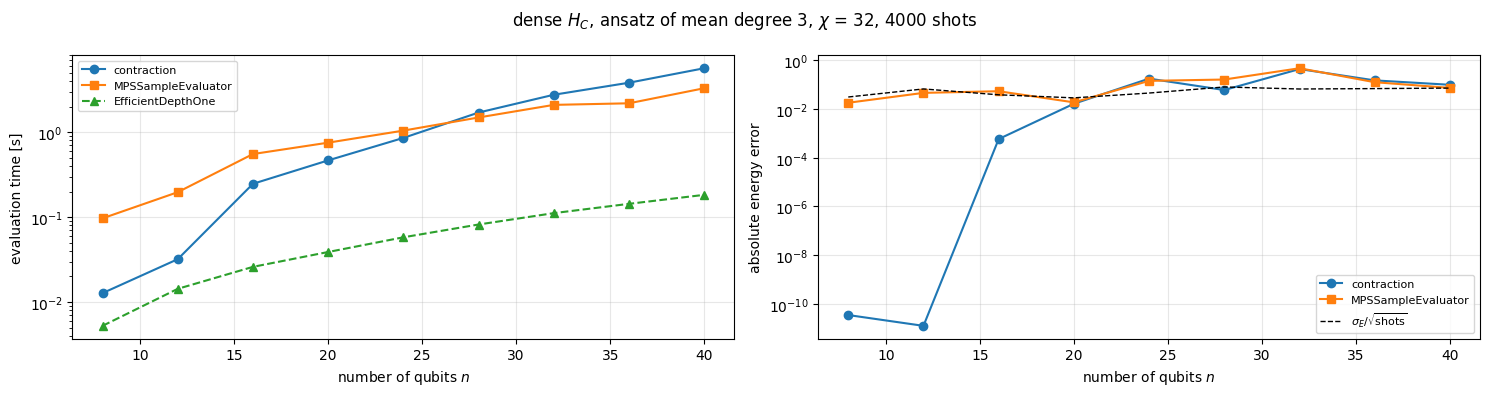

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
qubit_counts = [row["num_qubits"] for row in scaling_rows]

axes[0].plot(qubit_counts, [row["contraction_time"] for row in scaling_rows], "o-",
             label="contraction")
axes[0].plot(qubit_counts, [row["sampler_time"] for row in scaling_rows], "s-",
             label="MPSSampleEvaluator")
axes[0].plot(qubit_counts, [row["exact_time"] for row in scaling_rows], "^--",
             label="EfficientDepthOne")
axes[0].set_yscale("log")
axes[0].set_ylabel("evaluation time [s]")
axes[0].legend(fontsize=8)

# ratios = [row["sampler_time"] / row["contraction_time"] for row in scaling_rows]
# axes[1].plot(qubit_counts, ratios, "d-", color="tab:red")
# axes[1].axhline(1.0, color="k", lw=1, ls="--")
# axes[1].set_yscale("log")
# axes[1].set_ylabel("time ratio  sampler / contraction")
# axes[1].set_title("below 1: sampling is cheaper")

axes[1].plot(qubit_counts, [max(row["contraction_error"]/row["reference"], 1e-16) for row in scaling_rows], "o-",
             label="contraction")
axes[1].plot(qubit_counts, [row["sampler_error"]/row["reference"] for row in scaling_rows], "s-",
             label="MPSSampleEvaluator")
axes[1].plot(qubit_counts, [row["shot_noise"]/row["reference"] for row in scaling_rows], "k--", lw=1,
             label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")
axes[1].set_yscale("log")
axes[1].set_ylabel("absolute energy error")
axes[1].legend(fontsize=8)

for axis in axes:
    axis.set_xlabel("number of qubits $n$")
    axis.grid(alpha=0.3)

fig.suptitle(f"dense $H_C$, ansatz of mean degree {MEAN_DEGREE}, "
             f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots")
fig.tight_layout()
plt.show()

## 11. Where the sampler's time goes

The sampler's cost splits into the Aer circuit plus `shots` executions, which does not care how
dense $H_C$ is, and `energies()`, a Python loop over the unique bit strings scoring $H_C(x)$ term
by term, which does. The split says how much room is left to improve the sampler on dense cost
operators.

In [24]:
sampler = make_sample_evaluator()
_, total_times = timed(sampler.evaluate, cost_op, angles, ansatz_circuit=main_operator)
counts = sampler.get_results_from_last_iteration()["counts"]

loop_times = []
for _ in range(REPEATS):
    start = perf_counter()
    sampler.energies(counts)
    loop_times.append(perf_counter() - start)

total = float(np.median(total_times))
loop = float(np.median(loop_times))

print(f"unique bit strings out of {SHOTS} shots : {len(counts)}")
print(f"total evaluation                       : {total:.3f} s")
print(f"  Python energy loop                   : {loop:.3f} s  ({loop / total:.0%})")
print(f"  Aer circuit + sampling               : {total - loop:.3f} s  ({1 - loop / total:.0%})")

unique bit strings out of 4000 shots : 3462
total evaluation                       : 0.555 s
  Python energy loop                   : 0.165 s  (30%)
  Aer circuit + sampling               : 0.390 s  (70%)


## 12. Reading the results

Numbers are machine-dependent, so re-run before quoting them. The structure is robust.

**The hypothesis holds, with a crossover.** On a fully connected cost operator with a
mean-degree-3 ansatz, contraction wins at small $n$ -- it is faster *and* exact, so there is no
reason to sample -- and sampling wins beyond the crossover, by a margin that keeps growing with
$n$. Section 10 locates it; on this machine, at $\chi$ = `SWEEP_BOND_DIM`, it sits around
$n\approx 30$. Raising $\chi$ moves it to smaller $n$: both methods slow down with the bond
dimension, but the contraction slows down faster (compare the $\chi$ series in section 7, and
re-run section 10 with a larger `SWEEP_BOND_DIM` to see the crossing move).

**The mechanism is per-term cost** (section 9). The contraction is repeated once per Pauli term of
$H_C$, so its time grows with the density of the cost operator on top of everything else. The
sampler runs the circuit once regardless and touches $H_C$ only in the classical scoring pass. A
dense $H_C$ with a sparse ansatz is the combination that maximises this asymmetry: it inflates the
term count that the contraction pays for while keeping the circuit that the sampler pays for
cheap.

**Above the crossover the accuracy argument for contraction has also gone.** While $\chi$ suffices
the contraction is exact to simulator precision and no number of shots competes with it. But the
top-$|w|$ ansatz is sparse and *long-range*, so its entanglement outgrows a fixed $\chi$, and past
that point the contraction returns a truncated answer whose error is comparable to the sampler's
shot noise -- for a rapidly growing price. The regime where sampling wins is therefore the regime
where it wins twice.

**Practical consequences.**

* Pin `matrix_product_state_truncation_threshold` on both sides. `MPSSampleEvaluator` inherits
  Aer's `1e-16`; several Aer-based evaluators default it to `1e-5`, and left alone the accuracy
  comparison measures the mismatch instead of the method.
* `MPSAerEvaluator` is not the contraction: in local testing mode its `EstimatorV2` becomes a
  shot-based `BackendEstimatorV2` (section 1). Use `qiskit_aer.primitives.EstimatorV2` with
  `default_precision = 0` when a contraction is what you want.
* `MPSSampleEvaluator` also gives you CVaR (`cvar(energies, alpha)`) rather than just the mean,
  which the contraction cannot produce at any price.
* The sampler's remaining exposure to a dense $H_C$ is `energies()` (section 11). Packing the
  counts into a `(unique samples, n)` bit array and evaluating every term with NumPy parity
  products would push the crossover to smaller $n$ still.